<a href="https://colab.research.google.com/github/arturbernardo/word_vectors/blob/main/LLM_HOW_TO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Base de dados vetorial:

O planeta terra é precioso

Os astronautas viram a terra de longe

Na terra existe vida

terra: [

  é: 10%

  de: 14%

  existe: 1%

  a: 9%

  ...
  
]

preposições e artigos viram um problema

é: [

  feio: 0.01%

  bonito: 0.01%

  grande: 0.01%

  pequeno: 0.01%

  ... ++ 350 mil palavras
  
]



terra: [

  planeta: 5%

  astronautas: 2%

  vida: 4%

  ...

]

O carro ficou sujo de terra (...)

[planeta, astronauta, vida, aliens]

na verdade a palavra desejada era "no rali"

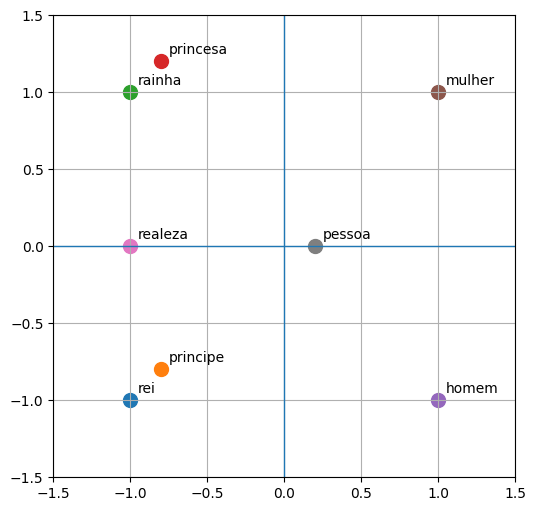

In [3]:
import matplotlib.pyplot as plt

palavras = {
    "rei":     [-1,-1],
    "rainha":  [-1, 1],
    "homem":   [1,-1],
    "mulher":  [1, 1],
}


palavras = {
    "rei":     [-1,-1],
    "rainha":  [-1, 1],
    "princesa":  [-0.8, 1.2],
    "homem":   [1,-1],
    "mulher":  [1, 1],
}

palavras = {
    "rei":     [-1,-1],
    "principe": [-0.8,-0.8],
    "rainha":  [-1, 1],
    "princesa": [-0.8, 1.2],
    "homem":   [1,-1],
    "mulher":  [1, 1],
    "realeza":  [-1, 0],
    "pessoa":  [0.2, 0],
}

plt.figure(figsize=(6,6))

for palavra, (x, y) in palavras.items():
    plt.scatter(x, y, s=100)
    plt.text(x + 0.05, y + 0.05, palavra)

# eixos cartesianos
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)


plt.grid(True)
plt.gca().set_aspect("equal")

plt.show()

In [17]:
import numpy as np

sentences = [

    ["brasil", "capital", "é", "brasilia"],
    ["franca", "capital", "é", "paris"],
    ["italia", "capital", "é", "roma"],
    ["alemanha", "capital", "é", "berlim"],
    ["japao", "capital", "é", "toquio"],

    ["japao", "produz", "anime"],
    ["japao", "produz", "vinho"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "linguiça"],
    ["italia", "produz", "vinho"],
    ["italia", "produz", "pizza"],
    ["franca", "produz", "baguete"],
    ["franca", "produz", "vinho"],
    ["brasil", "produz", "cachaça"],
    ["brasil", "produz", "cachaça"],

    ["cachaça", "é", "bebida"],
    ["cerveja", "é", "bebida"],
    ["vinho", "é", "bebida"],

    ["cachaça", "bebida"],
    ["cachaça", "bebida"],
    ["cerveja", "bebida"],
    ["vinho", "bebida"],
    ["cachaça", "bebida"],
    ["cerveja", "bebida"],
    ["vinho", "bebida"],
    ["cachaça", "bebida"],
    ["cerveja", "bebida"],
    ["vinho", "bebida"],


    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],



]

# palavras únicas
words = sorted(set(w for s in sentences for w in s))

vectors_default = {
    w: np.random.randn(2)
    for w in words
}

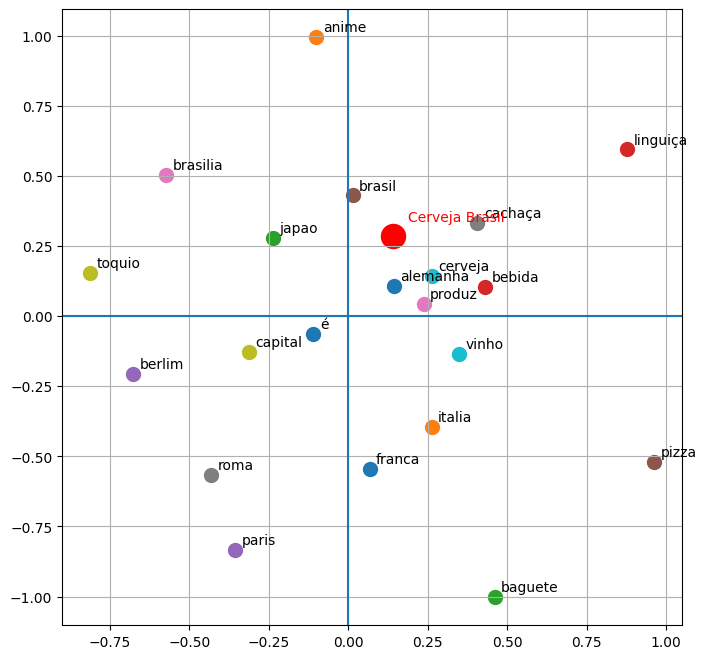

In [19]:
import matplotlib.pyplot as plt



# posição aleatória 2D inicial
vectors = vectors_default.copy();

learning_rate = 0.01
repulsion = 0.001

for epoch in range(1000):

    # atração: palavras que aparecem juntas
    for sentence in sentences:
        for i in range(len(sentence)):
            for j in range(i + 1, len(sentence)):

                w1 = sentence[i]
                w2 = sentence[j]

                v1 = vectors[w1]
                v2 = vectors[w2]

                delta = v2 - v1

                vectors[w1] += learning_rate * delta
                vectors[w2] -= learning_rate * delta

    # repulsão: evita tudo colapsar
    for w1 in words:
        for w2 in words:
            if w1 == w2:
                continue

            v1 = vectors[w1]
            v2 = vectors[w2]

            delta = v1 - v2
            dist = np.linalg.norm(delta) + 1e-6

            vectors[w1] += repulsion * delta / (dist ** 2)

# desenho
plt.figure(figsize=(8, 8))

for word, vec in vectors.items():
    x, y = vec

    plt.scatter(x, y, s=100)
    plt.text(x + 0.02, y + 0.02, word)



resultado = (
    (vectors["cerveja"]
    + vectors["brasil"])/2
)

plt.scatter(resultado[0], resultado[1], s=300, color="red")

plt.text(
    resultado[0] + 0.05,
    resultado[1] + 0.05,
    "Cerveja Brasil",
    color="red"
)


plt.axhline(0)
plt.axvline(0)

plt.grid(True)

plt.show()

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

corpus = [
    "empresa lucro",
    "ong doacao",
    "empresa doacao",
    "gato telhado"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

sim = cosine_similarity(X)

print(sim)

[[1.  0.  0.5 0. ]
 [0.  1.  0.5 0. ]
 [0.5 0.5 1.  0. ]
 [0.  0.  0.  1. ]]


1.0 = mesma direção
0.5 = direção parcialmente parecida
0.0 = direções sem nenhuma palavra em comum

cos(ângulo) = 0.5 = 60∘


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact


def circulo(angulo):
    theta = np.radians(angulo)

    x = np.cos(theta)
    y = np.sin(theta)

    fig, ax = plt.subplots(figsize=(6,6))

    t = np.linspace(0, 2*np.pi, 500)
    ax.plot(np.cos(t), np.sin(t))

    ax.axhline(0)
    ax.axvline(0)

    ax.plot([0, x], [0, y], linewidth=3)

    ax.plot([x, x], [0, y], linestyle='--')

    ax.scatter([x], [y], s=100)

    ax.text(0.05, 1.1,
            f"ângulo = {angulo}°\n"
            f"cos = {x:.3f}\n"
            f"sin = {y:.3f}",
            fontsize=12)

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

    ax.set_aspect('equal')

    plt.show()


interact(circulo, angulo=(1, 360, 1))

interactive(children=(IntSlider(value=180, description='angulo', max=360, min=1), Output()), _dom_classes=('wi…

<function __main__.circulo(angulo)>

In [25]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = ["o", "rei", "fujiu", "do", "reino"]
embeddings = model.encode(sentences)

from sklearn.metrics.pairwise import cosine_similarity
print(cosine_similarity(embeddings))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[1.0000001  0.29204395 0.27317104 0.40759495 0.36158746]
 [0.29204395 1.         0.2494547  0.21778983 0.47687414]
 [0.27317104 0.2494547  1.0000002  0.20646888 0.31079614]
 [0.40759495 0.21778983 0.20646888 1.         0.15925479]
 [0.36158746 0.47687414 0.31079614 0.15925479 1.        ]]


Vetores na LLM

In [ ]:
!pip install gensim tensorflow scikit-learn

In [21]:
import numpy as np
import gensim.downloader as api
import tensorflow as tf
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
wv = api.load("glove-wiki-gigaword-50")
embedding_dim = wv.vector_size

print("dimensão:", embedding_dim)
print(wv["king"][:10])

[==================================================] 100.0% 66.0/66.0MB downloaded
dimensão: 50
[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]


In [23]:
sentences = [
    "brazil produces coffee",
    "brazil produces sugar",
    "brazil produces soy",
    "france produces wine",
    "italy produces wine",
    "italy produces pizza",
    "germany produces beer",
    "japan produces anime",
    "japan produces technology",

    "coffee is drink",
    "wine is drink",
    "beer is drink",

    "dog likes park",
    "cat likes house",
    "bird likes tree",

    "car uses road",
    "truck uses road",
    "bike uses road",

    "python is language",
    "java is language",
    "javascript is language",
]

In [24]:
X = []
y = []
targets = []

for sentence in sentences:
    words = sentence.lower().split()

    input_words = words[:-1]
    target_word = words[-1]

    if target_word not in wv:
        continue

    input_vectors = []

    for word in input_words:
        if word in wv:
            input_vectors.append(wv[word])

    if len(input_vectors) == 0:
        continue

    # embedding da frase = média dos embeddings das palavras anteriores
    sentence_vector = np.mean(input_vectors, axis=0)

    X.append(sentence_vector)
    y.append(wv[target_word])
    targets.append(target_word)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)
print(targets)

(21, 50)
(21, 50)
['coffee', 'sugar', 'soy', 'wine', 'wine', 'pizza', 'beer', 'anime', 'technology', 'drink', 'drink', 'drink', 'park', 'house', 'tree', 'road', 'road', 'road', 'language', 'language', 'language']


In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(embedding_dim,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(embedding_dim)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse"
)

model.fit(X, y, epochs=500, verbose=0)

In [26]:
vocab = list(wv.index_to_key[:50000])
vocab_vectors = np.array([wv[word] for word in vocab])

In [27]:
def nearest_words(vector, topn=10):
    sims = cosine_similarity([vector], vocab_vectors)[0]
    best_ids = np.argsort(sims)[::-1][:topn]

    return [(vocab[i], sims[i]) for i in best_ids]

In [28]:
def predict_next_embedding(text, topn=10):
    words = text.lower().split()

    input_vectors = []

    for word in words:
        if word in wv:
            input_vectors.append(wv[word])

    if len(input_vectors) == 0:
        raise ValueError("Nenhuma palavra conhecida pelo embedding.")

    sentence_vector = np.mean(input_vectors, axis=0)

    predicted_vector = model.predict(
        np.array([sentence_vector]),
        verbose=0
    )[0]

    return nearest_words(predicted_vector, topn=topn)

In [29]:
predict_next_embedding("brazil produces")

[('sugar', np.float32(0.93483037)),
 ('coffee', np.float32(0.88037246)),
 ('soy', np.float32(0.87430555)),
 ('juice', np.float32(0.86682254)),
 ('corn', np.float32(0.8526748)),
 ('beans', np.float32(0.84053445)),
 ('milk', np.float32(0.83842814)),
 ('vegetable', np.float32(0.8333166)),
 ('syrup', np.float32(0.8274052)),
 ('fruit', np.float32(0.82654077))]

Transformer